In [1]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace
from omegaconf import DictConfig, OmegaConf
from typing import Any
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preprocess the files 

In [2]:
def get_model(filename: str):
    cfg = OmegaConf.create({'load_model': filename})
    model_path, run_cfg = _load_run(cfg)
    with open(model_path, "rb") as f:
        saved = pickle.load(f)
    model = saved["model"]
    feature_cols = saved["feature_cols"]
    feat_params = SimpleNamespace(**saved["feat_params"])
    return model, feature_cols, feat_params, run_cfg

In [3]:
def build_data(run_cfg: DictConfig, feat_params: Any):
    pothole_df, weather_df = build_daily(run_cfg)
    feat_df = assemble_features(pothole_df, weather_df, feat_params)
    feat_df = make_split(feat_df, run_cfg.split, feat_params)
    return feat_df

In [4]:
def get_results(f: str, horizon: int = 1): 
    model, feature_cols, feat_params, run_cfg = get_model(f)
    print(f"Feature params: {feat_params}")
    feat_df = build_data(run_cfg, feat_params)

    # get test data
    test_df = feat_df[feat_df["split"] == "test"]
    X_test = test_df[feature_cols]
    y_test = test_df["Y"]

    # get predictions
    y_test_preds = model.predict(X_test, recursive = True, horizon=horizon)

    return y_test, y_test_preds, test_df, model


# Plot a single result


In [8]:
f = "ward3_naive_last_week_20091231_20251231_20260514_6cfe8c51"
model, feature_cols, feat_params, run_cfg = get_model(f)


In [10]:
feat_params.d


1

In [9]:
print(f"Feature params: {feat_params}")
feat_df = build_data(run_cfg, feat_params)

Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, d_sm07=15, l_sm07=0, d_sm728=15, l_sm728=0, k_AR=0)
[assemble_features] kept 5821/6101 rows (95.4%) after dropping NaNs


In [12]:
# get test data
test_df = feat_df[feat_df["split"] == "test"]
X_test = test_df[feature_cols]
y_test = test_df["Y"]

In [16]:
# get predictions
y_test_preds, select_idx = model.predict(X_test, recursive = True, d=feat_params.d, horizon_h=5, \
    assimilate=True, Ys = y_test, return_index=True)

In [17]:
selected_dates = test_df.date.iloc[select_idx]
selected_y_test = y_test.iloc[select_idx]

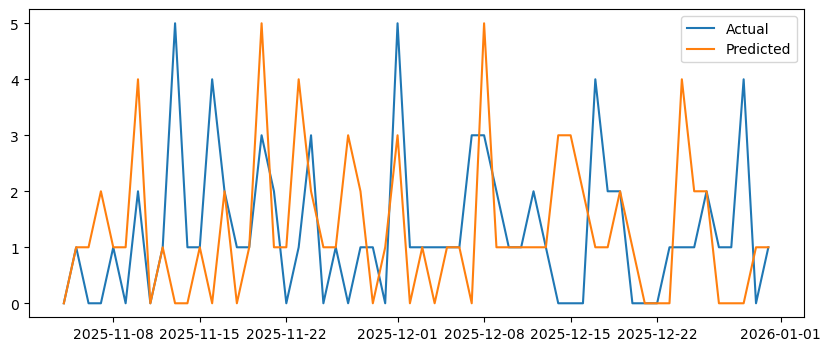

In [18]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot()
ax.plot(selected_dates, selected_y_test, label="Actual")
ax.plot(selected_dates, y_test_preds, label="Predicted")
ax.legend()
plt.show()